# <center>PROYECTO INVESTIGACIÓN - EJERCICIO 2<center>

<left>Brais Fojo Couce - brais.fojo@udc.es<left>  
<left>Rodrigo Romay Aba - rodrigo.romay@udc.es<left>

## Librerías necesarias

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgb2gray, gray2rgb, rgb2hsv
from skimage.feature import hog, local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

## Preprocesado
### El primer paso es preprocesar los datos para dejarlos en un formato adecuado para el análisis posterior. Esto incluye:
- Definir una semilla (42) para asegurar la reproducibilidad de los resultados.
- Cargar las imágenes y las máscaras, aplicar las máscaras y posteriormente reescalarlo todo a un tamaño adecuado (target_size).

Cargando dataset desde: DataSet_2/objects
 -> Procesando 'elephant': 64 imágenes.
 -> Procesando 'rhino': 59 imágenes.
 -> Procesando 'emu': 53 imágenes.
 -> Procesando 'flamingo': 67 imágenes.
Carga finalizada.
Dimensiones X: (243, 128, 128, 3)
Dimensiones y: (243,)


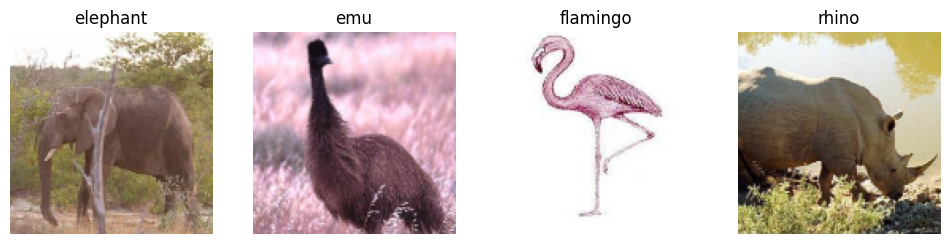

In [2]:
SEED = 42 # reproducibilidad

BASE_PATH = "DataSet_2/objects" 
CLASSES = ["elephant", "rhino", "emu", "flamingo"] 
IMG_SIZE = (128, 128) # Tamaño reescalado

def load_and_process(base_path, classes, target_size): # Función para cargar imágenes y aplicar máscaras
    images_list = []
    labels_list = []
    
    path_images_root = os.path.join(base_path, "images")
    path_masks_root = os.path.join(base_path, "masks")
    
    print(f"Cargando dataset desde: {base_path}")
    
    for class_name in classes:
        class_img_dir = os.path.join(path_images_root, class_name)
        class_mask_dir = os.path.join(path_masks_root, class_name)
        
        if not os.path.exists(class_img_dir):
            continue
            
        files = sorted([f for f in os.listdir(class_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f" -> Procesando '{class_name}': {len(files)} imágenes.")
        
        for file_name in files:
            # Cargar imagen
            p_img = os.path.join(class_img_dir, file_name)
            try:
                img = imread(p_img)
            except:
                continue
                
            # Normalizamos todo a RGB (3 canales)
            if img.ndim == 2:
                img = gray2rgb(img)
            # Si tiene canal Alfa (RGBA), lo quitamos
            elif img.shape[2] == 4:
                img = img[:,:,:3]

            #Buscar máscara
            name_no_ext = os.path.splitext(file_name)[0]
            mask_path = None
            
            for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
                candidate = os.path.join(class_mask_dir, name_no_ext + ext)
                if os.path.exists(candidate):
                    mask_path = candidate
                    break
            
            # Aplicar Máscara
            if mask_path:
                mask = imread(mask_path)
                
                # asegurar máscara binaria 2D del mismo tamaño que la imagen
                if mask.ndim == 3: mask = rgb2gray(mask)
                mask = resize(mask, (img.shape[0], img.shape[1]), order=0, preserve_range=True) > 0
                
                # multiplicar la imagen por la máscara (expandimos máscara a 3 canales para operar)
                img = img * mask[:,:,np.newaxis]

            # Redimensionar
            img_final = resize(img, target_size, anti_aliasing=True)
            
            images_list.append(img_final)
            labels_list.append(class_name)
            
    return np.array(images_list), np.array(labels_list)

# Ejecucción

try:
    X, y = load_and_process(BASE_PATH, CLASSES, IMG_SIZE)
    
    print(f"Carga finalizada.")
    print(f"Dimensiones X: {X.shape}") 
    print(f"Dimensiones y: {y.shape}")

    # Visualización para asegurar el correcto cargado y procesado de datos
    if len(X) > 0:
        unique_classes = np.unique(y)
        fig, axes = plt.subplots(1, len(unique_classes), figsize=(12, 4))
        for i, cls in enumerate(unique_classes):
            idx = np.where(y == cls)[0][0]
            axes[i].imshow(X[idx])
            axes[i].set_title(cls)
            axes[i].axis('off')
        plt.show()

except Exception as e:
    print(f"Error: {e}")

## Extracción de características
### El segundo paso es extraer toda la información relevante y necesaria para entrenar adecuadamente. Esto incluye:
- Forma (HOG).
- Textura (LBP).
- Espacios cromáticos (RBG y HSV)

In [3]:

# Configuración
HOG_PARAMS = {
    'orientations': 9, 
    'pixels_per_cell': (16, 16), 
    'cells_per_block': (2, 2), 
    'visualize': False, 
    'channel_axis': -1
}

LBP_RADIUS = 3
LBP_POINTS = 8 * LBP_RADIUS
LBP_METHOD = 'uniform'

COLOR_BINS = 32

# Funciones de extracción de características individuales

# Forma
def get_hog_features(img):
    return hog(img, **HOG_PARAMS)

# Histograma genérico (sirve para RGB o HSV)
def get_color_hist(img, bins=COLOR_BINS):
    h1, _ = np.histogram(img[:,:,0], bins=bins, range=(0, 256)) # Canal 1
    h2, _ = np.histogram(img[:,:,1], bins=bins, range=(0, 256)) # Canal 2
    h3, _ = np.histogram(img[:,:,2], bins=bins, range=(0, 256)) # Canal 3
    
    # Concatenar y normalizar
    hist = np.concatenate((h1, h2, h3)).astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# Textura (necesita escala de grises)
def get_lbp_features(img):
    gray = rgb2gray(img)
    # Convertir a entero 0-255 para LBP
    gray_uint = (gray * 255).astype(np.uint8)
    
    lbp = local_binary_pattern(gray_uint, LBP_POINTS, LBP_RADIUS, LBP_METHOD)
    
    # Hacemos un histograma de los patrones de textura encontrados
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist

# Función de extracción de características

def extract_global_features(X_images, features_to_use=['hog', 'rgb']):
    feature_list = []
    
    for img in X_images:
        img_vectors = []
        
        # 1. HOG 
        if 'hog' in features_to_use:
            img_vectors.append(get_hog_features(img))
            
        # 2. RGB 
        if 'rgb' in features_to_use:
            img_vectors.append(get_color_hist(img))
            
        # 3. HSV 
        if 'hsv' in features_to_use:
            img_hsv = rgb2hsv(img) * 255 
            img_vectors.append(get_color_hist(img_hsv))
            
        # 4. LBP 
        if 'lbp' in features_to_use:
            img_vectors.append(get_lbp_features(img))
        
        # Concatenar todo lo seleccionado
        if len(img_vectors) > 0:
            combined = np.hstack(img_vectors)
            feature_list.append(combined)
        else:
            print("Error: No has seleccionado ninguna característica válida.")
            return None
        
    return np.array(feature_list)

## Comparativa de características usando SVM
### Por último, entrenamos un modelo de SVM con diferentes conjuntos de características para ver cual es la más interesante y relevante. Para ello, utilizamos las siquientes combinaciones: (Solo Color (RGB), Solo Forma (HOG), HOG + RGB, Full (HOG+HSV+LBP))
- reetiquetamos a 3 etiquetas como se pide ('rhino', 'elephant' y 'resto')
- Separamos en conjuntos (train y test, 75% y 25%)
- Definimos el modelo SVM con los hiperparámetros que mejor rendimiento nos ha dado (kernel gaussiano).
- Entrenamos el modelo para la toma de resultados.
- Mostramos una tabla con estadísticas para cada conjunto de características y una tabla resumen final.


   Solo Color (RGB)
   Características: ['rgb']
              precision    recall  f1-score   support

    elephant       0.00      0.00      0.00        16
       resto       0.49      1.00      0.66        30
       rhino       0.00      0.00      0.00        15

    accuracy                           0.49        61
   macro avg       0.16      0.33      0.22        61
weighted avg       0.24      0.49      0.32        61



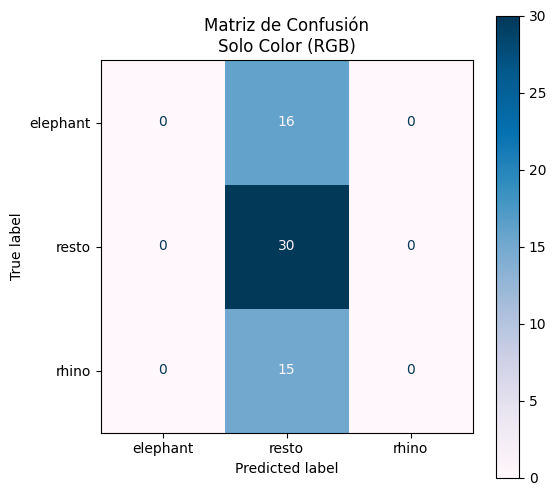


   Solo Forma (HOG)
   Características: ['hog']
              precision    recall  f1-score   support

    elephant       1.00      0.75      0.86        16
       resto       0.91      0.97      0.94        30
       rhino       0.88      1.00      0.94        15

    accuracy                           0.92        61
   macro avg       0.93      0.91      0.91        61
weighted avg       0.92      0.92      0.92        61



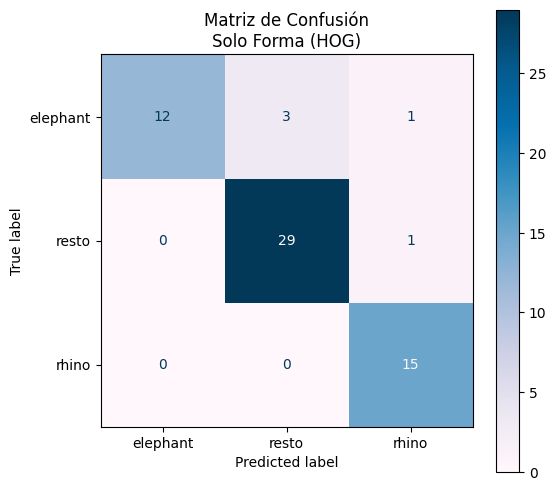


   HOG + RGB
   Características: ['hog', 'rgb']
              precision    recall  f1-score   support

    elephant       1.00      0.75      0.86        16
       resto       0.91      0.97      0.94        30
       rhino       0.88      1.00      0.94        15

    accuracy                           0.92        61
   macro avg       0.93      0.91      0.91        61
weighted avg       0.92      0.92      0.92        61



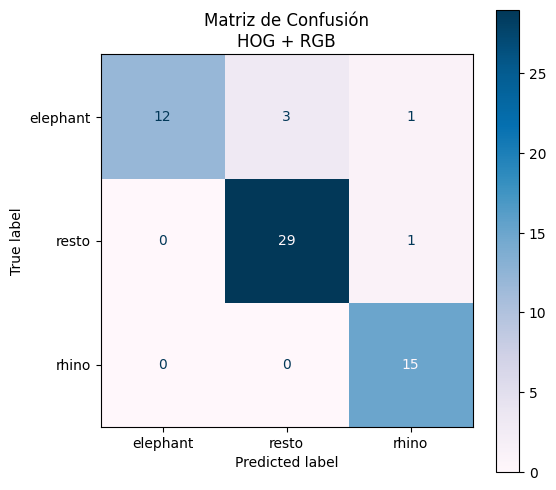


   Full (HOG+HSV+LBP)
   Características: ['hog', 'hsv', 'lbp']
              precision    recall  f1-score   support

    elephant       0.92      0.75      0.83        16
       resto       0.88      1.00      0.94        30
       rhino       1.00      0.93      0.97        15

    accuracy                           0.92        61
   macro avg       0.94      0.89      0.91        61
weighted avg       0.92      0.92      0.92        61



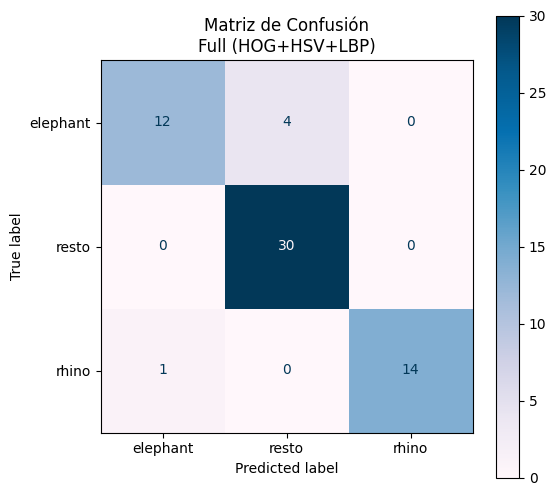


############################################################
TABLA COMPARATIVA FINAL
############################################################
EXPERIMENTO                    | ACCURACY   | F1-SCORE  
------------------------------------------------------------
Solo Color (RGB)               | 0.4918     | 0.3243
Solo Forma (HOG)               | 0.9180     | 0.9154
HOG + RGB                      | 0.9180     | 0.9154
Full (HOG+HSV+LBP)             | 0.9180     | 0.9156
------------------------------------------------------------


In [4]:
# reetiquetado a 'rhino', 'elephant' y 'resto'

y_3_clases = []
for label in y: 
    if label == 'elephant':
        y_3_clases.append('elephant')
    elif label == 'rhino':
        y_3_clases.append('rhino')
    else:
        y_3_clases.append('resto')

y_3_clases = np.array(y_3_clases)

# Aquí definimos qué características vamos a probar en cada ronda
experiments_config = {
    "Solo Color (RGB)":   ['rgb'],                 
    "Solo Forma (HOG)":   ['hog'],                  
    "HOG + RGB":          ['hog', 'rgb'],           
    "Full (HOG+HSV+LBP)": ['hog', 'hsv', 'lbp']    
}

summary_metrics = []

# Ejecucion

for exp_name, features_list in experiments_config.items():
    print(f"\n{'='*60}")
    print(f"   {exp_name}")
    print(f"   Características: {features_list}")
    print(f"{'='*60}")
    
    # Extracción
    X_exp = extract_global_features(X, features_to_use=features_list)
    
    # Separación de conjuntos
    X_train, X_test, y_train, y_test = train_test_split(
        X_exp, 
        y_3_clases, 
        test_size=0.25, 
        random_state=SEED, 
        stratify=y_3_clases
    )
    
    # Entrenar
    classifier = Pipeline([
        ('scaler', StandardScaler()), 
        ('svm', SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)) 
    ])
    
    classifier.fit(X_train, y_train)

    # Calcular y guardar métricas
    y_pred = classifier.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    summary_metrics.append({'Model': exp_name, 'Accuracy': acc, 'F1-Score': f1})
    
    # Visualización
    print(classification_report(y_test, y_pred, zero_division=0))

    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        ax=ax, 
        cmap='PuBu', 
        normalize=None 
    )
    plt.title(f"Matriz de Confusión\n{exp_name}")
    plt.show()

# Tabla final
print("\n" + "#"*60)
print("TABLA COMPARATIVA FINAL")
print("#"*60)
print(f"{'EXPERIMENTO':<30} | {'ACCURACY':<10} | {'F1-SCORE':<10}")
print("-" * 60)

for m in summary_metrics:
    print(f"{m['Model']:<30} | {m['Accuracy']:.4f}     | {m['F1-Score']:.4f}")

print("-" * 60)

## Conclusiones finales
Observando los resultados, Se concluye que la forma (HOG) es la característica determinante, ya que el color falla al compartir ambas clases tonalidades grises. HOG captura las diferencias estructurales clave (trompa vs cuerno), logrando por sí solo la máxima precisión. Añadir más descriptores no mejoró los resultados, confirmando que la información de la silueta es suficiente para resolver este problema.